# Learning by Pruning — Weight-Level (Input Weights)

Weight-level conversion of `learning_by_pruning_3layer_true_categorical.ipynb`. Single hidden layer (`x → W1 → ltu → W2 → logits`), pruning **input weights (W1)** by default. The `PRUNE_W1` / `PRUNE_W2` flags decide which layer(s) get pruned. Output weights default to identity (`USE_IDEAL_OUTPUT_WEIGHTS = True`), which forces `HIDDEN_SIZE == OUTPUT_SIZE`.

**Hidden-unit signal** (always softmax CE):
- *LOO* utility per unit (descriptive — each unit has an associated utility, but pruning happens at the weight level here)
- *FLIP* utility per unit → derives `target_activations[i] ∈ {0, 1}` and an `informative[i]` mask (active units, plus dead units that should be on)

**Input-weight (W1) utility variants** (all four are compared in the final cell):
1. L1 LOO (`|e + c| − |e|`, e = target − preact) **with** informative mask
2. L1 LOO **without** informative mask
3. BCE LOO (preact treated as logit, target as binary label) **with** informative mask
4. BCE LOO **without** informative mask

When `PRUNE_W2 = True`, output-weight (W2) utility is the per-weight softmax-CE LOO from the prior weight-level notebook.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

from phd.jax_core.models import ltu

# ── Architecture ──────────────────────────────────────────────────────
INPUT_SIZE = 784
HIDDEN_SIZE = 10            # must equal OUTPUT_SIZE when USE_IDEAL_OUTPUT_WEIGHTS=True
OUTPUT_SIZE = 10
USE_IDEAL_OUTPUT_WEIGHTS = True

# ── Pruning ───────────────────────────────────────────────────────────
PRUNE_W1 = True             # prune input weights
PRUNE_W2 = False            # prune output weights
WEIGHTS_PER_PRUNE = 10

# ── Schedule ──────────────────────────────────────────────────────────
PRUNE_EVERY = 500
PRINT_EVERY = 5_000
TRACE_DECAY = 1.0 - (1.0 / PRUNE_EVERY)
RESET_TRACES_ON_PRUNE = False
SEED = 260326
SCAN_UNROLL = 10

In [2]:
# ── Load MNIST ────────────────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True, download=True)

all_images_np = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
all_labels_np = train_dataset.targets.numpy()
print(f'Loaded {len(all_labels_np)} training images')

Loaded 60000 training images


In [3]:
# ── Forward + utility functions ───────────────────────────────────────

def forward(x, W1, W2, mask1, mask2):
    preact = x @ (W1 * mask1)         # (hidden,)
    h = ltu(preact)                   # (hidden,) — binary
    logits = h @ (W2 * mask2)         # (out,)
    return logits, h, preact


# ── Hidden-unit utilities (always softmax CE) ─────────────────────────

def hidden_unit_softmax_ce_loo(h, W2, mask2, logits, one_hot):
    """Per-unit softmax-CE LOO utility. ΔCE if unit i is removed."""
    c = (W2 * mask2) * h[:, None]                    # (hidden, out)
    logits_wo = logits[None, :] - c                  # (hidden, out)
    log_p = jax.nn.log_softmax(logits)
    log_p_wo = jax.nn.log_softmax(logits_wo, axis=-1)
    ce = -jnp.sum(one_hot * log_p)
    ce_wo = -jnp.sum(one_hot[None, :] * log_p_wo, axis=-1)
    return ce_wo - ce                                # (hidden,)


def hidden_unit_softmax_ce_flip(h, W2, mask2, logits, one_hot):
    """Per-unit softmax-CE flip utility. Works for dead units too."""
    flip = 1.0 - 2.0 * h                             # (hidden,)
    delta = flip[:, None] * (W2 * mask2)             # (hidden, out)
    logits_flip = logits[None, :] + delta
    log_p = jax.nn.log_softmax(logits)
    log_p_flip = jax.nn.log_softmax(logits_flip, axis=-1)
    ce = -jnp.sum(one_hot * log_p)
    ce_flip = -jnp.sum(one_hot[None, :] * log_p_flip, axis=-1)
    return ce_flip - ce


def hidden_unit_targets(h, U_flip):
    """Target activation ∈ {0, 1} and informative mask, derived from flip utility."""
    active = h > 0.0
    should_be_on = (active & (U_flip > 0.0)) | ((~active) & (U_flip < 0.0))
    informative = active | ((~active) & (U_flip < 0.0))
    return should_be_on.astype(jnp.float32), informative.astype(jnp.float32)


# ── W1 weight utilities (4 variants) ──────────────────────────────────

def _w1_l1_loo(x, W1, mask1, preact, target_activations, informative):
    """Per-weight L1 LOO. error = target - preact; |e + c| - |e|."""
    c = (W1 * mask1) * x[:, None]                                # (in, hidden)
    error = target_activations - preact                          # (hidden,)
    U = jnp.abs(error[None, :] + c) - jnp.abs(error[None, :])    # (in, hidden)
    if informative is not None:
        U = U * informative[None, :]
    return U


def _w1_bce_loo(x, W1, mask1, preact, target_activations, informative):
    """Per-weight BCE LOO. preact is logit, target_activations is binary label."""
    c = (W1 * mask1) * x[:, None]
    preact_wo = preact[None, :] - c                              # (in, hidden)
    lp = (target_activations * jax.nn.log_sigmoid(preact)
          + (1 - target_activations) * jax.nn.log_sigmoid(-preact))
    lp_wo = (target_activations[None, :] * jax.nn.log_sigmoid(preact_wo)
             + (1 - target_activations)[None, :] * jax.nn.log_sigmoid(-preact_wo))
    U = (-lp_wo) - (-lp[None, :])                                # ΔBCE per weight
    if informative is not None:
        U = U * informative[None, :]
    return U


# Wrappers that bake in the use-informative flag so a single function pointer
# fully specifies the utility variant (lets us swap variants without re-tracing
# manually; each new closure forces JIT to re-trace).
def w1_l1_with_informative(x, W1, mask1, preact, target_activations, informative):
    return _w1_l1_loo(x, W1, mask1, preact, target_activations, informative)

def w1_l1_no_informative(x, W1, mask1, preact, target_activations, informative):
    return _w1_l1_loo(x, W1, mask1, preact, target_activations, None)

def w1_bce_with_informative(x, W1, mask1, preact, target_activations, informative):
    return _w1_bce_loo(x, W1, mask1, preact, target_activations, informative)

def w1_bce_no_informative(x, W1, mask1, preact, target_activations, informative):
    return _w1_bce_loo(x, W1, mask1, preact, target_activations, None)


# ── W2 weight utility (per-weight softmax CE LOO; from the prior notebook) ─

def w2_softmax_ce_loo(h, W2, mask2, error, targets):
    logits = targets - error                                     # one_hot - error
    log_p = jax.nn.log_softmax(logits)
    diag = jnp.eye(OUTPUT_SIZE, dtype=jnp.bool_)
    log_p_off = jnp.where(diag, -jnp.inf, log_p[None, :])        # (out, out)
    log_1mp = jax.scipy.special.logsumexp(log_p_off, axis=-1)
    d = -h[:, None] * W2                                         # (hidden, out)
    a = log_1mp[None, :]
    b = d + log_p[None, :]
    return (-d * targets[None, :] + jnp.logaddexp(a, b)) * mask2


# Default W1 utility for the single-run cell below
W1_UTIL_FN = w1_bce_with_informative

In [ ]:
# ── Scan step builder + experiment runner ────────────────────────────

def _make_scan_step(w1_util_fn):
    def _scan_step(carry, data):
        W1, W2, mask1, mask2, ut1, ut2 = carry
        x, label = data

        one_hot = jax.nn.one_hot(label, OUTPUT_SIZE)

        logits, h, preact = forward(x, W1, W2, mask1, mask2)
        correct = (jnp.argmax(logits) == label).astype(jnp.float32)

        # Hidden-unit signal: per-unit LOO (descriptive) + FLIP (drives targets).
        # U_unit_loo gives every unit an associated utility but isn't used to make
        # pruning decisions in this notebook (pruning happens at the weight level).
        U_unit_loo = hidden_unit_softmax_ce_loo(h, W2, mask2, logits, one_hot)
        U_unit_flip = hidden_unit_softmax_ce_flip(h, W2, mask2, logits, one_hot)
        target_activations, informative = hidden_unit_targets(h, U_unit_flip)

        # W1 weight utility trace — selected variant
        U1 = w1_util_fn(x, W1, mask1, preact, target_activations, informative)
        ut1 = ut1 * TRACE_DECAY + U1 * (1 - TRACE_DECAY)

        # W2 weight utility trace — always computed (cheap; only used if PRUNE_W2)
        error = one_hot - logits
        U2 = w2_softmax_ce_loo(h, W2, mask2, error, one_hot)
        ut2 = ut2 * TRACE_DECAY + U2 * (1 - TRACE_DECAY)

        carry = (W1, W2, mask1, mask2, ut1, ut2)
        return carry, correct
    return _scan_step


def make_scan_fn(w1_util_fn):
    """Build a fresh JIT-compiled scan over the chosen W1 utility variant."""
    step_fn = _make_scan_step(w1_util_fn)
    return jax.jit(lambda carry, data: jax.lax.scan(step_fn, carry, data, unroll=SCAN_UNROLL))


def _prune_weights(mask1, mask2, ut1, ut2, prune_w1, prune_w2, n_to_prune, cap1, cap2):
    """Prune up to n_to_prune weights, respecting per-layer 'leave at least 1' caps."""
    if prune_w1 and not prune_w2:
        score = jnp.where(mask1 > 0.5, ut1, jnp.inf).reshape(-1)
        _, idx = jax.lax.top_k(-score, n_to_prune)
        rows = idx // HIDDEN_SIZE
        cols = idx % HIDDEN_SIZE
        return mask1.at[rows, cols].set(0.0), mask2

    if prune_w2 and not prune_w1:
        score = jnp.where(mask2 > 0.5, ut2, jnp.inf).reshape(-1)
        _, idx = jax.lax.top_k(-score, n_to_prune)
        rows = idx // OUTPUT_SIZE
        cols = idx % OUTPUT_SIZE
        return mask1, mask2.at[rows, cols].set(0.0)

    # Both layers — pool, oversample, then assign respecting per-layer caps.
    s1 = jnp.where(mask1 > 0.5, ut1, jnp.inf).reshape(-1)
    s2 = jnp.where(mask2 > 0.5, ut2, jnp.inf).reshape(-1)
    flat = jnp.concatenate([s1, s2])
    n1 = int(s1.size)
    k_sample = int(min(flat.size, n_to_prune * 2))
    _, idx = jax.lax.top_k(-flat, k_sample)
    idx_np = np.array(idx)

    n_p1 = n_p2 = 0
    for i_global in idx_np:
        if n_p1 + n_p2 == n_to_prune:
            break
        i_global = int(i_global)
        if i_global < n1:
            if n_p1 < cap1:
                row, col = i_global // HIDDEN_SIZE, i_global % HIDDEN_SIZE
                mask1 = mask1.at[row, col].set(0.0)
                n_p1 += 1
        else:
            local = i_global - n1
            if n_p2 < cap2:
                row, col = local // OUTPUT_SIZE, local % OUTPUT_SIZE
                mask2 = mask2.at[row, col].set(0.0)
                n_p2 += 1
    return mask1, mask2


def _init_state(seed):
    key = jax.random.PRNGKey(seed)
    k1, k2 = jax.random.split(key)
    W1 = jax.random.normal(k1, (INPUT_SIZE, HIDDEN_SIZE)) * np.sqrt(2.0 / INPUT_SIZE)
    if USE_IDEAL_OUTPUT_WEIGHTS:
        assert HIDDEN_SIZE == OUTPUT_SIZE, \
            'USE_IDEAL_OUTPUT_WEIGHTS requires HIDDEN_SIZE == OUTPUT_SIZE'
        W2 = jnp.eye(HIDDEN_SIZE)
    else:
        W2 = jax.random.normal(k2, (HIDDEN_SIZE, OUTPUT_SIZE)) * np.sqrt(2.0 / HIDDEN_SIZE)
    mask1 = jnp.ones((INPUT_SIZE, HIDDEN_SIZE))
    mask2 = jnp.ones((HIDDEN_SIZE, OUTPUT_SIZE))
    ut1 = jnp.zeros((INPUT_SIZE, HIDDEN_SIZE))
    ut2 = jnp.zeros((HIDDEN_SIZE, OUTPUT_SIZE))
    return W1, W2, mask1, mask2, ut1, ut2


def _total_prune_events(prune_w1, prune_w2, weights_per_prune):
    total = 0
    if prune_w1:
        total += INPUT_SIZE * HIDDEN_SIZE - 1
    if prune_w2:
        total += HIDDEN_SIZE * OUTPUT_SIZE - 1
    if total <= 0:
        return 0
    return (total + weights_per_prune - 1) // weights_per_prune


def run_pruning(w1_util_fn, prune_w1, prune_w2, weights_per_prune, seed=SEED, verbose=True):
    W1, W2, mask1, mask2, ut1, ut2 = _init_state(seed)
    scan_fn = make_scan_fn(w1_util_fn)

    rng = np.random.RandomState(seed)
    epoch_order = rng.permutation(len(all_labels_np))
    epoch_pos = 0

    def get_chunk(size):
        nonlocal epoch_order, epoch_pos
        indices = []
        remaining = size
        while remaining > 0:
            avail = len(epoch_order) - epoch_pos
            take = min(avail, remaining)
            indices.append(epoch_order[epoch_pos:epoch_pos + take])
            epoch_pos += take
            remaining -= take
            if epoch_pos >= len(epoch_order):
                epoch_order = rng.permutation(len(all_labels_np))
                epoch_pos = 0
        return np.concatenate(indices)

    n_prune_events = _total_prune_events(prune_w1, prune_w2, weights_per_prune)
    chunks_per_print = PRINT_EVERY // PRUNE_EVERY

    all_corrects = []
    n_active1_history = []
    n_active2_history = []

    carry = (W1, W2, mask1, mask2, ut1, ut2)

    for prune_idx in range(n_prune_events):
        indices = get_chunk(PRUNE_EVERY)
        data = (jnp.array(all_images_np[indices]), jnp.array(all_labels_np[indices]))

        carry, corrects = scan_fn(carry, data)
        all_corrects.append(np.array(corrects))

        W1, W2, mask1, mask2, ut1, ut2 = carry
        n_active1 = int(mask1.sum())
        n_active2 = int(mask2.sum())
        n_active1_history.append(n_active1)
        n_active2_history.append(n_active2)

        cap1 = max(0, n_active1 - 1) if prune_w1 else 0
        cap2 = max(0, n_active2 - 1) if prune_w2 else 0
        n_to_prune = min(weights_per_prune, cap1 + cap2)
        if n_to_prune > 0:
            mask1, mask2 = _prune_weights(mask1, mask2, ut1, ut2, prune_w1, prune_w2,
                                          n_to_prune, cap1, cap2)
            if RESET_TRACES_ON_PRUNE:
                ut1 = jnp.zeros_like(ut1)
                ut2 = jnp.zeros_like(ut2)
        carry = (W1, W2, mask1, mask2, ut1, ut2)

        step_num = (prune_idx + 1) * PRUNE_EVERY
        if verbose and step_num % PRINT_EVERY == 0:
            recent = all_corrects[-chunks_per_print:]
            recent_acc = float(np.concatenate(recent).mean()) * 100
            print(f'Step {step_num:>8d} | W1: {n_active1:>6d}/{INPUT_SIZE * HIDDEN_SIZE} '
                  f'| W2: {n_active2:>4d}/{HIDDEN_SIZE * OUTPUT_SIZE} | Acc: {recent_acc:.1f}%')

    if verbose:
        print(f'Done. W1 active: {int(mask1.sum())}/{INPUT_SIZE * HIDDEN_SIZE}, '
              f'W2 active: {int(mask2.sum())}/{HIDDEN_SIZE * OUTPUT_SIZE}')

    return {
        'all_corrects': all_corrects,
        'n_active1_history': n_active1_history,
        'n_active2_history': n_active2_history,
    }


def plot_run(name, result):
    all_corrects = result['all_corrects']
    n1 = result['n_active1_history']
    n2 = result['n_active2_history']

    if not all_corrects:
        print(f'{name}: no pruning events ran (PRUNE_W1 and PRUNE_W2 both False?).')
        return

    acc_per_interval = [c.mean() * 100 for c in all_corrects]
    interval_centers = [(i + 0.5) * PRUNE_EVERY for i in range(len(acc_per_interval))]

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(interval_centers, acc_per_interval, color='tab:blue', linewidth=1.5, label='Accuracy')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Accuracy (%)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, 100)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(interval_centers, n1, color='tab:red', linewidth=1.5, linestyle='--', label='W1 active')
    ax2.plot(interval_centers, n2, color='tab:orange', linewidth=1.5, linestyle=':', label='W2 active')
    ax2.set_ylabel('Active weights')

    fig.suptitle(f'Learning by Pruning — Weight-Level — {name}', fontsize=13)
    fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
    fig.tight_layout()
    plt.show()

## Single Run

Runs once with the W1 utility configured above (`W1_UTIL_FN`) and the `PRUNE_W1` / `PRUNE_W2` flags from the config block.

Step     5000 | W1:   7750/7840 | W2:  100/100 | Acc: 14.3%
Step    10000 | W1:   7650/7840 | W2:  100/100 | Acc: 27.8%
Step    15000 | W1:   7550/7840 | W2:  100/100 | Acc: 37.7%
Step    20000 | W1:   7450/7840 | W2:  100/100 | Acc: 44.8%
Step    25000 | W1:   7350/7840 | W2:  100/100 | Acc: 46.7%
Step    30000 | W1:   7250/7840 | W2:  100/100 | Acc: 50.5%
Step    35000 | W1:   7150/7840 | W2:  100/100 | Acc: 53.4%
Step    40000 | W1:   7050/7840 | W2:  100/100 | Acc: 54.8%
Step    45000 | W1:   6950/7840 | W2:  100/100 | Acc: 55.4%
Step    50000 | W1:   6850/7840 | W2:  100/100 | Acc: 57.0%
Step    55000 | W1:   6750/7840 | W2:  100/100 | Acc: 56.6%
Step    60000 | W1:   6650/7840 | W2:  100/100 | Acc: 58.0%
Step    65000 | W1:   6550/7840 | W2:  100/100 | Acc: 59.4%
Step    70000 | W1:   6450/7840 | W2:  100/100 | Acc: 59.2%
Step    75000 | W1:   6350/7840 | W2:  100/100 | Acc: 60.1%
Step    80000 | W1:   6250/7840 | W2:  100/100 | Acc: 59.8%
Step    85000 | W1:   6150/7840 | W2:  1

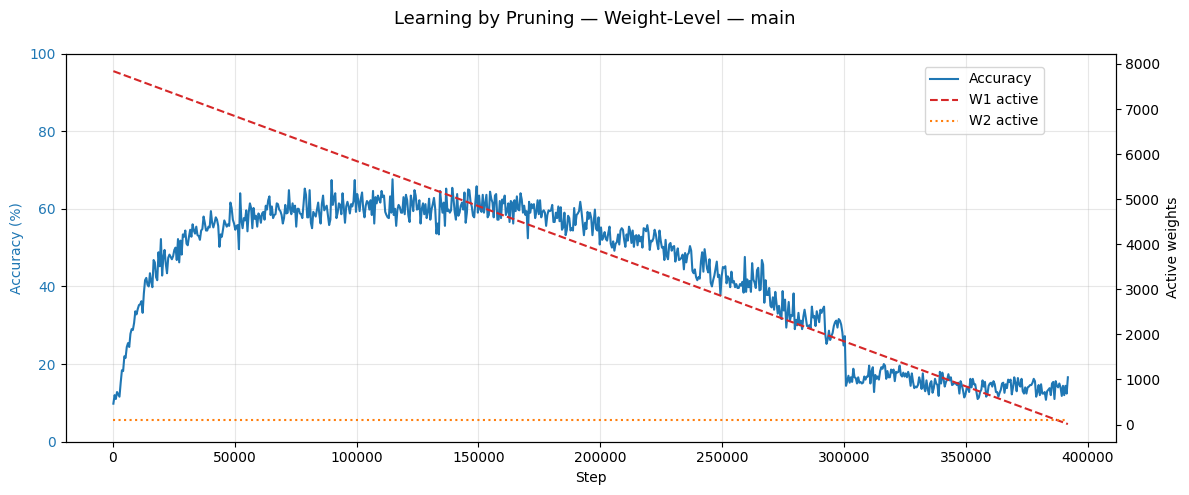

In [7]:
result = run_pruning(W1_UTIL_FN, PRUNE_W1, PRUNE_W2, WEIGHTS_PER_PRUNE)
plot_run('main', result)

## All W1 Utility Variants

Run all four input-weight utility variants in sequence. Each variant gets its own plot as soon as it finishes. The `PRUNE_W1` / `PRUNE_W2` flags from the config block are honored — by default this loop only prunes input weights.


=== L1 LOO + informative ===
Step     5000 | W1:   7750/7840 | W2:  100/100 | Acc: 15.8%
Step    10000 | W1:   7650/7840 | W2:  100/100 | Acc: 30.6%
Step    15000 | W1:   7550/7840 | W2:  100/100 | Acc: 36.5%
Step    20000 | W1:   7450/7840 | W2:  100/100 | Acc: 44.7%
Step    25000 | W1:   7350/7840 | W2:  100/100 | Acc: 43.7%
Step    30000 | W1:   7250/7840 | W2:  100/100 | Acc: 46.9%
Step    35000 | W1:   7150/7840 | W2:  100/100 | Acc: 48.7%
Step    40000 | W1:   7050/7840 | W2:  100/100 | Acc: 49.2%
Step    45000 | W1:   6950/7840 | W2:  100/100 | Acc: 50.0%
Step    50000 | W1:   6850/7840 | W2:  100/100 | Acc: 51.3%
Step    55000 | W1:   6750/7840 | W2:  100/100 | Acc: 51.9%
Step    60000 | W1:   6650/7840 | W2:  100/100 | Acc: 51.8%
Step    65000 | W1:   6550/7840 | W2:  100/100 | Acc: 52.6%
Step    70000 | W1:   6450/7840 | W2:  100/100 | Acc: 53.9%
Step    75000 | W1:   6350/7840 | W2:  100/100 | Acc: 53.8%
Step    80000 | W1:   6250/7840 | W2:  100/100 | Acc: 53.0%
Step    85

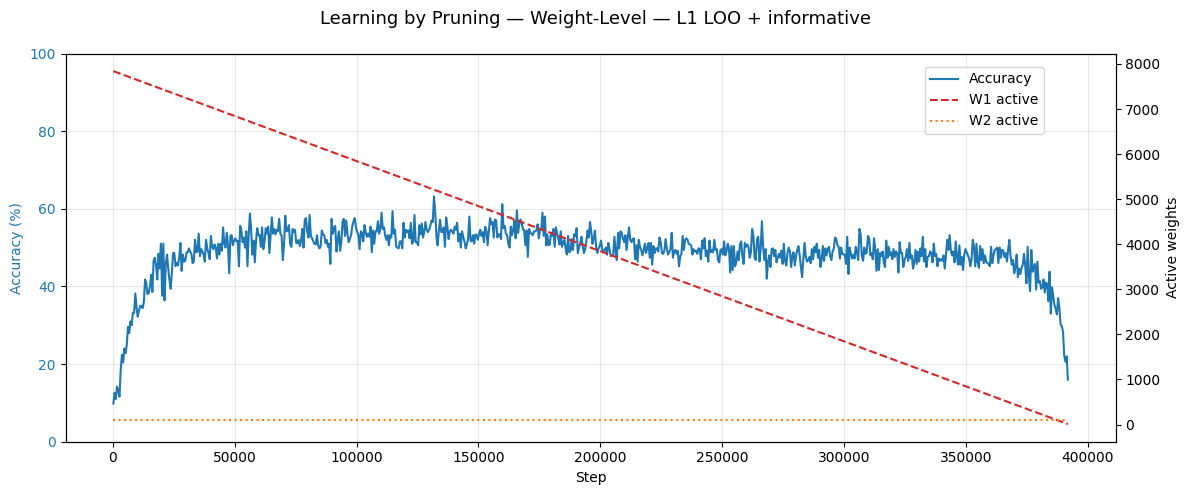


=== L1 LOO + no informative ===
Step     5000 | W1:   7750/7840 | W2:  100/100 | Acc: 10.8%
Step    10000 | W1:   7650/7840 | W2:  100/100 | Acc: 12.9%
Step    15000 | W1:   7550/7840 | W2:  100/100 | Acc: 14.6%
Step    20000 | W1:   7450/7840 | W2:  100/100 | Acc: 15.6%
Step    25000 | W1:   7350/7840 | W2:  100/100 | Acc: 16.0%
Step    30000 | W1:   7250/7840 | W2:  100/100 | Acc: 16.7%
Step    35000 | W1:   7150/7840 | W2:  100/100 | Acc: 18.6%
Step    40000 | W1:   7050/7840 | W2:  100/100 | Acc: 17.5%
Step    45000 | W1:   6950/7840 | W2:  100/100 | Acc: 17.2%
Step    50000 | W1:   6850/7840 | W2:  100/100 | Acc: 17.4%
Step    55000 | W1:   6750/7840 | W2:  100/100 | Acc: 18.4%
Step    60000 | W1:   6650/7840 | W2:  100/100 | Acc: 17.6%
Step    65000 | W1:   6550/7840 | W2:  100/100 | Acc: 18.2%
Step    70000 | W1:   6450/7840 | W2:  100/100 | Acc: 18.1%
Step    75000 | W1:   6350/7840 | W2:  100/100 | Acc: 19.6%
Step    80000 | W1:   6250/7840 | W2:  100/100 | Acc: 19.1%
Step   

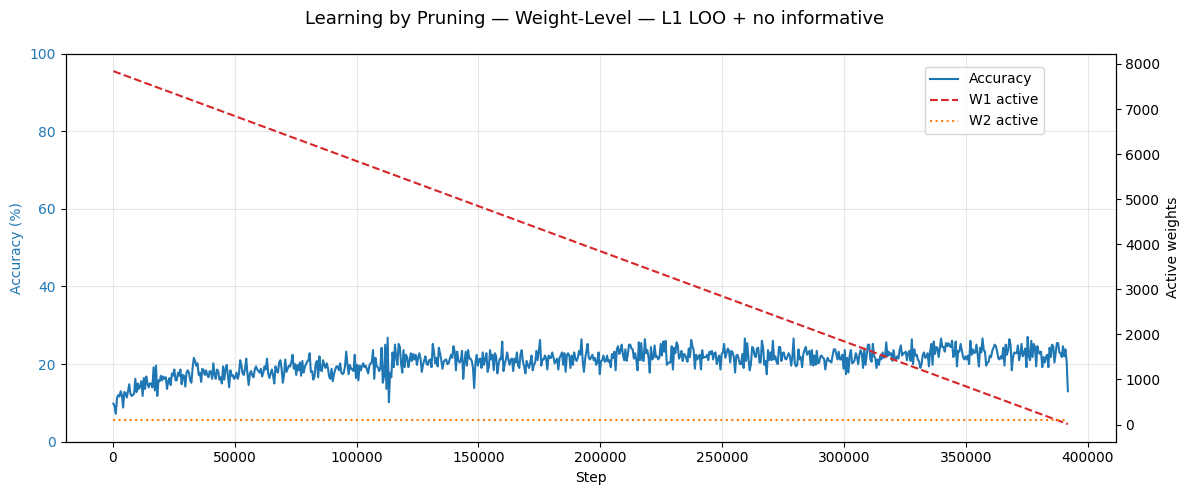


=== BCE LOO + informative ===
Step     5000 | W1:   7750/7840 | W2:  100/100 | Acc: 14.3%
Step    10000 | W1:   7650/7840 | W2:  100/100 | Acc: 27.8%
Step    15000 | W1:   7550/7840 | W2:  100/100 | Acc: 37.7%
Step    20000 | W1:   7450/7840 | W2:  100/100 | Acc: 44.8%
Step    25000 | W1:   7350/7840 | W2:  100/100 | Acc: 46.7%
Step    30000 | W1:   7250/7840 | W2:  100/100 | Acc: 50.5%
Step    35000 | W1:   7150/7840 | W2:  100/100 | Acc: 53.4%
Step    40000 | W1:   7050/7840 | W2:  100/100 | Acc: 54.8%
Step    45000 | W1:   6950/7840 | W2:  100/100 | Acc: 55.4%
Step    50000 | W1:   6850/7840 | W2:  100/100 | Acc: 57.0%
Step    55000 | W1:   6750/7840 | W2:  100/100 | Acc: 56.6%
Step    60000 | W1:   6650/7840 | W2:  100/100 | Acc: 58.0%
Step    65000 | W1:   6550/7840 | W2:  100/100 | Acc: 59.4%
Step    70000 | W1:   6450/7840 | W2:  100/100 | Acc: 59.2%
Step    75000 | W1:   6350/7840 | W2:  100/100 | Acc: 60.1%
Step    80000 | W1:   6250/7840 | W2:  100/100 | Acc: 59.8%
Step    8

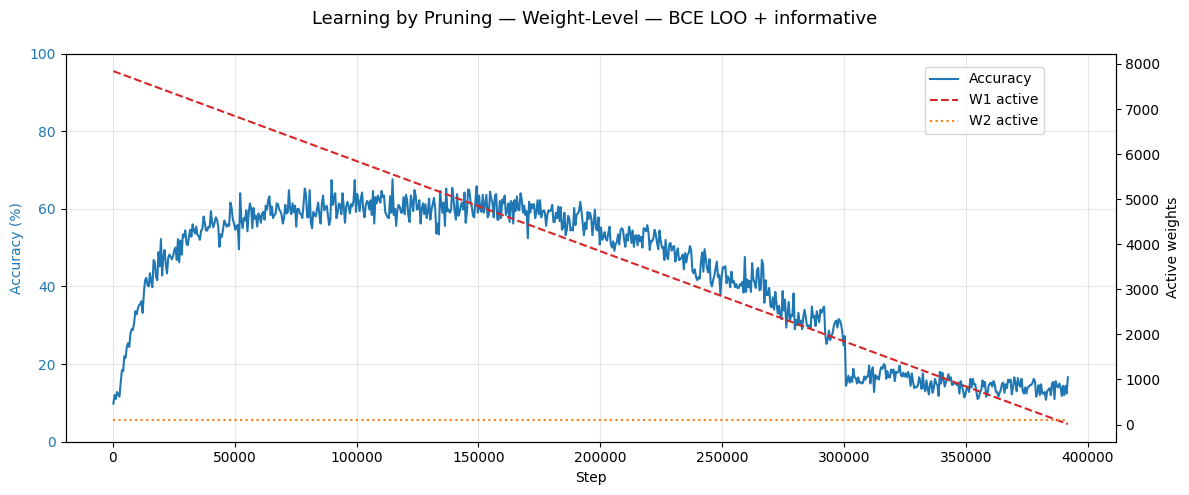


=== BCE LOO + no informative ===
Step     5000 | W1:   7750/7840 | W2:  100/100 | Acc: 12.4%
Step    10000 | W1:   7650/7840 | W2:  100/100 | Acc: 11.2%
Step    15000 | W1:   7550/7840 | W2:  100/100 | Acc: 9.8%
Step    20000 | W1:   7450/7840 | W2:  100/100 | Acc: 9.1%
Step    25000 | W1:   7350/7840 | W2:  100/100 | Acc: 9.6%
Step    30000 | W1:   7250/7840 | W2:  100/100 | Acc: 9.7%
Step    35000 | W1:   7150/7840 | W2:  100/100 | Acc: 10.9%
Step    40000 | W1:   7050/7840 | W2:  100/100 | Acc: 9.7%
Step    45000 | W1:   6950/7840 | W2:  100/100 | Acc: 9.5%
Step    50000 | W1:   6850/7840 | W2:  100/100 | Acc: 9.7%
Step    55000 | W1:   6750/7840 | W2:  100/100 | Acc: 10.5%
Step    60000 | W1:   6650/7840 | W2:  100/100 | Acc: 9.8%
Step    65000 | W1:   6550/7840 | W2:  100/100 | Acc: 10.6%
Step    70000 | W1:   6450/7840 | W2:  100/100 | Acc: 9.8%
Step    75000 | W1:   6350/7840 | W2:  100/100 | Acc: 9.6%
Step    80000 | W1:   6250/7840 | W2:  100/100 | Acc: 9.8%
Step    85000 | W

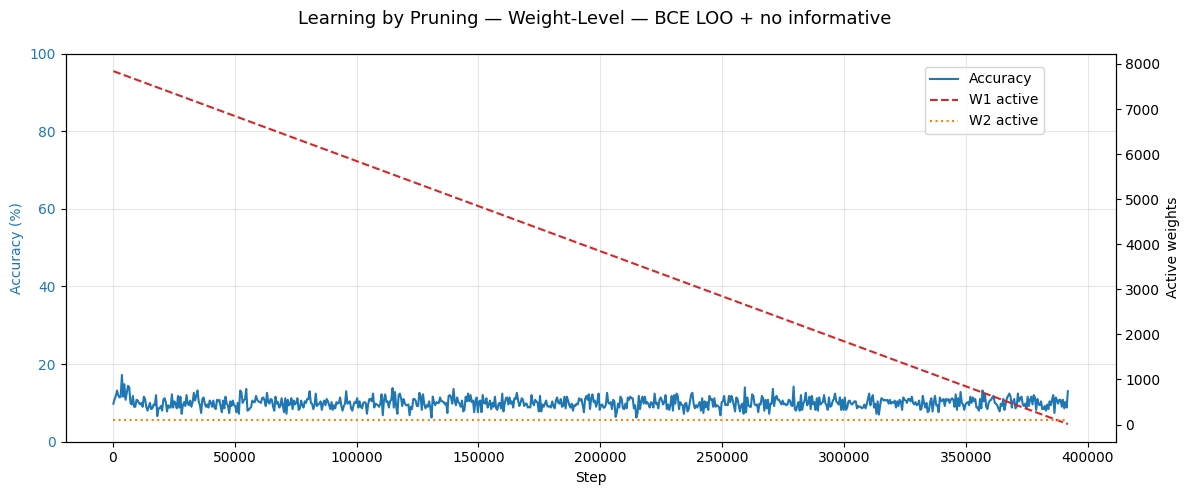

In [ ]:
W1_UTIL_FNS = {
    'L1 LOO + informative':     w1_l1_with_informative,
    'L1 LOO + no informative':  w1_l1_no_informative,
    'BCE LOO + informative':    w1_bce_with_informative,
    'BCE LOO + no informative': w1_bce_no_informative,
}

all_results = {}
for util_name, util_fn in W1_UTIL_FNS.items():
    print(f'\n=== {util_name} ===')
    result = run_pruning(util_fn, PRUNE_W1, PRUNE_W2, WEIGHTS_PER_PRUNE)
    plot_run(util_name, result)
    all_results[util_name] = result